<a href="https://colab.research.google.com/github/KweonTJ/Machine_Learning/blob/main/7_Convolutional_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7.1 합성곱 구현
- 필터를 다양하게 생성하여 이미지와 합성곱 구현
- 실습을 통해 합성곱 연산 원리 이해
- matplotlib : png 파일 읽기. 이미지를 읽어 넘파이 배열 형태로 반환, 넘파이 배열로 필터를 생성하여 필터가 이미지를 표현하는 배열에 곱하기.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from urllib.request import urlopen
from PIL import Image

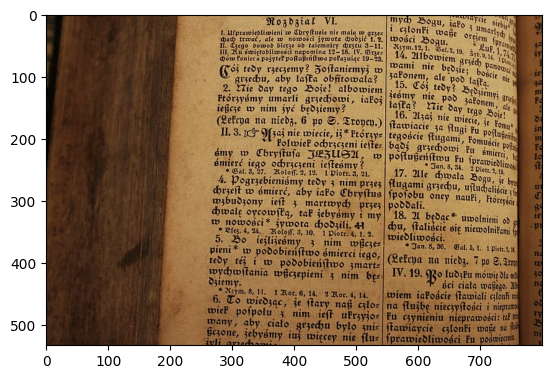

In [3]:
url = 'https://github.com/dknife/ML/raw/main/data/image/book.png'
img = Image.open(urlopen(url))
plt.imshow(img)
img = np.asarray(img)

def padding(image, p_size):
  padded_img = np.pad(
      array = image,
      pad_width = ((p_size, p_size), (p_size, p_size), (0, 0)),
      mode = 'constant', constant_values= 0)
  return padded_img

(537, 804, 3)

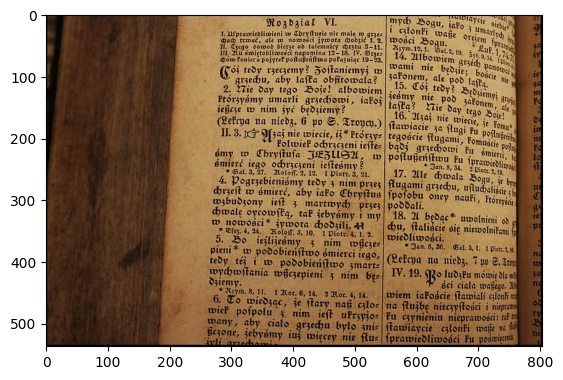

In [4]:
padded = padding(img, 2)
plt.imshow(padded)
padded.shape

In [5]:
box_filter = np.array(
    [[1/9, 1/9, 1/9],
     [1/9, 1/9, 1/9],
     [1/9, 1/9, 1/9]])

In [6]:
def apply_filter(small_region, filter):
  conv = np.multiply(small_region, filter)
  return np.sum(conv)

In [8]:
def convolution(img, filter):
  r, c, channels = img.shape
  rp, cp = filter.shape
  th_r, th_c = (rp-1)//2, (cp-1)//2

  start = np.array([ th_r, th_c])
  end = np.array([r, c]) - start
  print(start, end, rp, cp)
  conv_img = np.zeros((r - th_r*2, c - th_c*2, channels))

  for channel in range(channels):
    for i in range(start[0], end[0]):
      for j in range(start[1], end[1]):
        conv_img[i-th_r, j-th_c, channel] = round(apply_filter(
            img[i-th_r:i+th_r+1, j-th_c:j+th_c+1, channel],
            filter))/255

  conv_img = np.clip(conv_img, 0, 1)
  return conv_img

[1 1] [536 803] 3 3


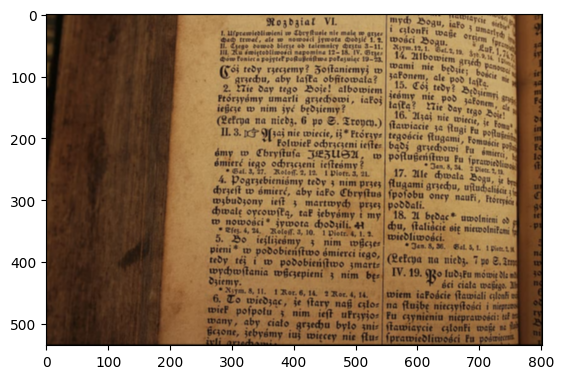

In [9]:
conv_img = convolution(padded, box_filter)
plt.imshow(conv_img)

[1 1] [536 803] 3 3


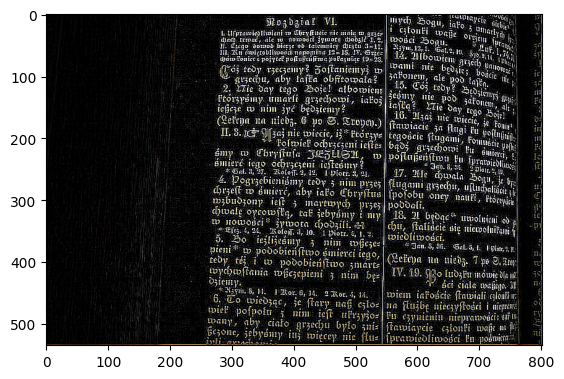

In [10]:
laplacian = np.array(
    [[1, 0, 1],
    [0, -4, 0],
    [1, 0, 1],])
conv_img = convolution(padded, laplacian)
plt.imshow(conv_img)

[1 1] [536 803] 3 3


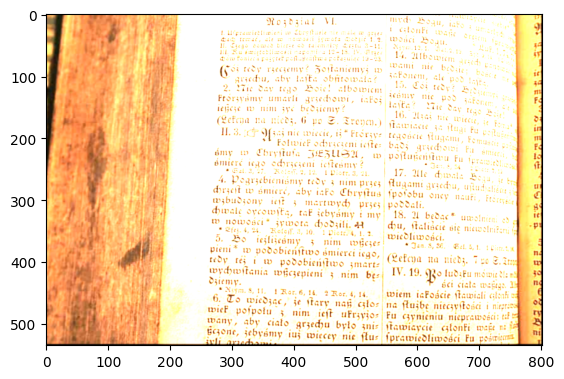

In [11]:
unknown = np.random.rand(3, 3)
conv_img = convolution(padded, unknown)
plt.imshow(conv_img)

# 7.2 합성곱 신경망으로 패션 MNIST 분류 개선


In [13]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [14]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
print(train_images.shape)
print(train_labels)
print(test_images.shape)

(60000, 28, 28)
[9 0 0 ... 3 0 5]
(10000, 28, 28)


In [16]:
train_images = train_images[:, :, :, np.newaxis]
test_images = test_images[:, :, :, np.newaxis]

In [17]:
model = keras.models.Sequential([
    keras.layers.Conv2D(input_shape=(28, 28, 1),
                        kernel_size=(3, 3),
                        padding='same',
                        filters=32),
    keras.layers.MaxPooling2D((2, 2), strides=2),

    keras.layers.Conv2D(kernel_size=(3, 3),
                        padding='same',
                        filters=64),
    keras.layers.MaxPooling2D((2, 2), strides=2),

    keras.layers.Conv2D(kernel_size=(3, 3),
                        padding='same',
                        filters=32),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,570 (947.54 KB)

 Trainable params: 242,570 (947.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_images, train_labels,
                    epochs=5,
                    validation_split=0.25)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 44ms/step - accuracy: 0.8050 - loss: 0.6734 - val_accuracy: 0.8553 - val_loss: 0.4077
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.8758 - loss: 0.3533 - val_accuracy: 0.8795 - val_loss: 0.3448
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.8890 - loss: 0.3128 - val_accuracy: 0.8757 - val_loss: 0.3669
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.8941 - loss: 0.2992 - val_accuracy: 0.8847 - val_loss: 0.3228
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 88s 48ms/step - accuracy: 0.8976 - loss: 0.2911 - val_accuracy: 0.8815 - val_loss: 0.3338


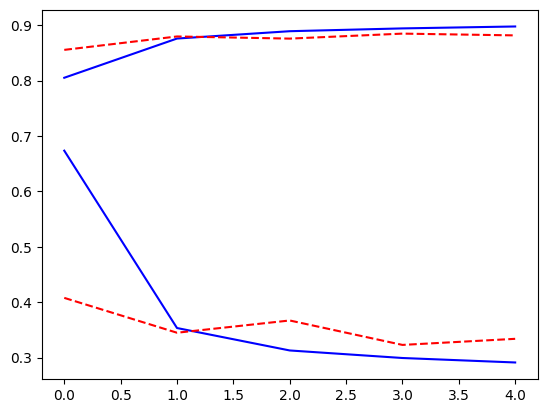

In [20]:
plt.plot(history.history['loss'], 'b-')
plt.plot(history.history['val_loss'], 'r--')

plt.plot(history.history['accuracy'], 'b-')
plt.plot(history.history['val_accuracy'], 'r--')

In [21]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print('테스트 정확도:', test_acc)

313/313 - 5s - 15ms/step - accuracy: 0.8708 - loss: 0.3618
테스트 정확도: 0.8708000183105469


In [22]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [23]:
randIdx = np.random.randint(0, 1000)

images = test_images[randIdx:randIdx+25]
predictions = np.argmax(model.predict(images), axis=1)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
[4 7 4 2 6 5 6 1 2 1 3 0 9 1 0 9 3 6 7 9 9 4 4 7 1]


In [24]:
def plot_images(images, labels, images_per_row=5):
    n_images = len(images)
    n_rows = (n_images - 1) // images_per_row + 1

    fig, ax = plt.subplots(n_rows, images_per_row,
                           figsize=(images_per_row * 2, n_rows * 2))

    for i in range(n_rows):
        for j in range(images_per_row):
            if i * images_per_row + j >= n_images:
                break

            img_idx = i * images_per_row + j
            a_image = images[img_idx].reshape(28, 28)

            if n_rows > 1:
                axis = ax[i, j]
            else:
                axis = ax[j]

            axis.get_xaxis().set_visible(False)
            axis.get_yaxis().set_visible(False)

            label = class_names[labels[img_idx]]
            axis.set_title(label)
            axis.imshow(a_image, cmap='gray', interpolation='nearest')

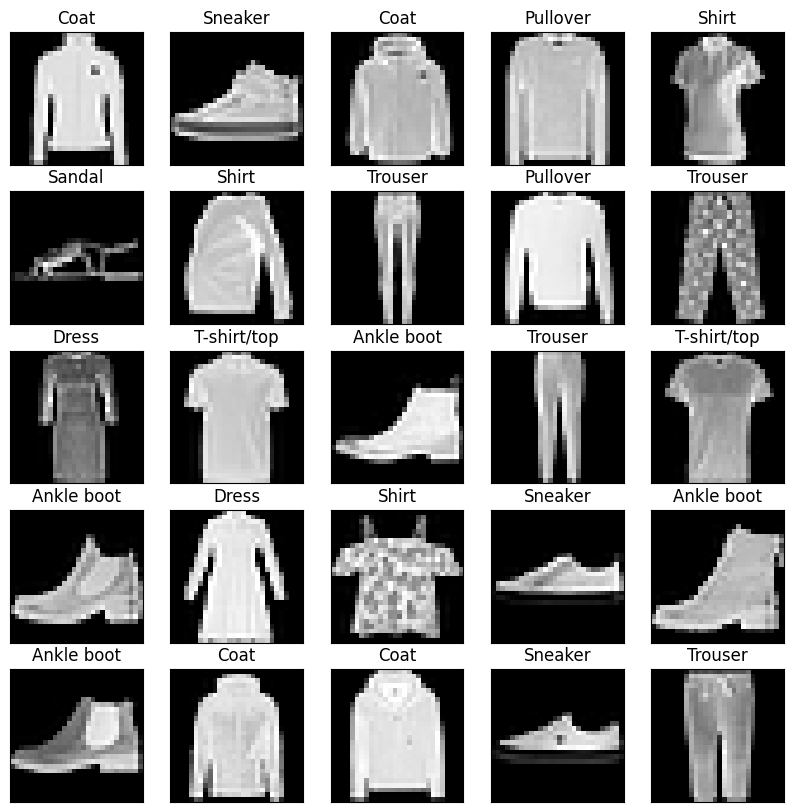

In [25]:
plot_images(images, predictions, images_per_row=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


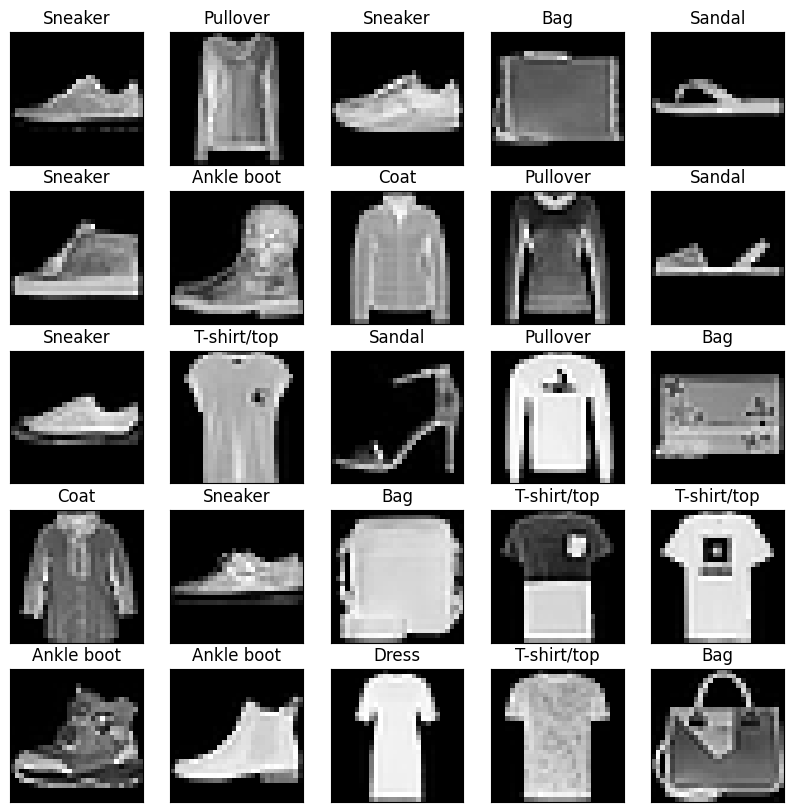

In [26]:
randIdx = np.random.randint(0, 1000)

images = test_images[randIdx:randIdx+25]
predictions = np.argmax(model.predict(images), axis=1)
plot_images(images, predictions, images_per_row=5)

# 7.3 성능 좋은 CNN 활용

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from skimage.transform import resize
from keras.applications.inception_v3 import preprocess_input, InceptionV3
from keras import models, layers
from keras.models import Model, load_model
import pandas as pd
from keras.optimizers import RMSprop

In [3]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# 훈련 10000개, 검증 2000개
x_train, x_test = x_train[:10000] / 255.0, x_test[:2000] / 255.0
y_train, y_test = y_train[:10000], y_test[:2000]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
x_train_preprocess = np.zeros((x_train.shape[0], 75, 75, 3),
                              dtype=np.float32)
print(x_train_preprocess.shape)

for i, img in enumerate(x_train):
    img_resize = resize(img, (75, 75), anti_aliasing=True)
    x_train_preprocess[i] = np.dstack([img_resize, img_resize, img_resize])

(10000, 75, 75, 3)


In [5]:
x_test_preprocess = np.zeros((x_test.shape[0], 75, 75, 3),
                             dtype=np.float32)
print(x_test_preprocess.shape)

for i, img in enumerate(x_test):
    img_resize = resize(img, (75, 75), anti_aliasing=True)
    x_test_preprocess[i] = np.dstack([img_resize, img_resize, img_resize])

(2000, 75, 75, 3)


In [6]:
pre_trained_model = InceptionV3(
    input_shape=(75, 75, 3),
    include_top=False,
    weights=None)

pre_trained_model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 37, 37,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 37, 37,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 35, 35,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 35, 35,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 17, 17,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 17, 17,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 15, 15,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [7]:
last_layer = pre_trained_model.get_layer('mixed7')
last_output = last_layer.output

x = layers.Flatten()(last_output)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dense(10, activation='softmax')(x)

In [8]:
model = Model(pre_trained_model.input, x)

model.compile(optimizer=RMSprop(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
history = model.fit(x_train_preprocess, y_train, epochs=20,
    validation_data=(x_test_preprocess, y_test)
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 149ms/step - accuracy: 0.7952 - loss: 1.2200 - val_accuracy: 0.5035 - val_loss: 3.4455
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9500 - loss: 0.1956 - val_accuracy: 0.8555 - val_loss: 0.9071
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.9645 - loss: 0.1429 - val_accuracy: 0.9670 - val_loss: 0.1409
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9737 - loss: 0.1027 - val_accuracy: 0.8925 - val_loss: 0.3744
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.9790 - loss: 0.0766 - val_accuracy: 0.9530 - val_loss: 0.1489
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.9825 - loss: 0.0680 - val_accuracy: 0.9765 - val_loss: 0.1044
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.9866 - loss: 0.0492 - val_accuracy: 0.9825 - val_loss: 0.0726
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.9877 - loss: 0.0462 

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

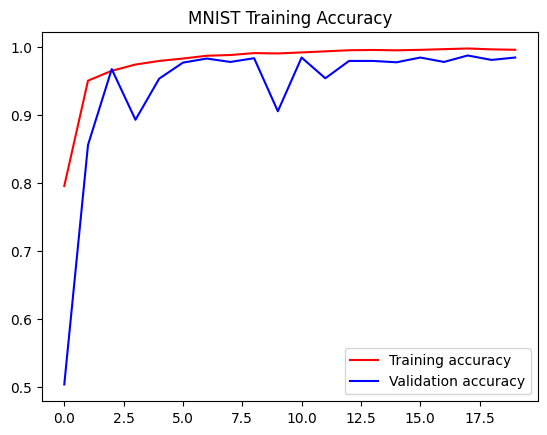

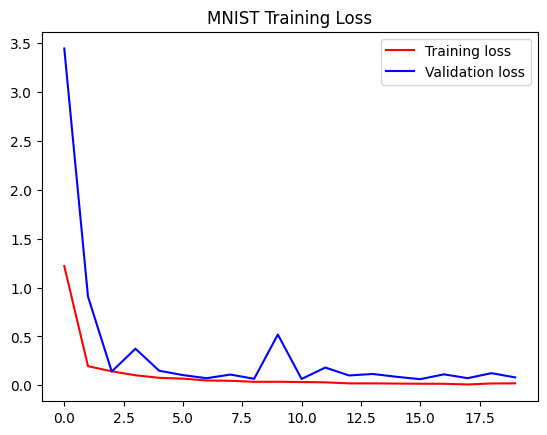

In [12]:
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('MNIST Training Accuracy')
plt.legend(loc=0)
plt.show()
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('MNIST Training Loss')
plt.legend(loc=0)
plt.show()